# Predição de ativos da bolsa de valores

## Import Libraries

In [1]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
from plotly.offline import plot
import plotly.graph_objects as go

import datetime
import pandas as pd
from sklearn.utils import class_weight
import utils
from glob import glob

In [2]:
import xgboost as xgb
import tensorflow as tf

from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Input, Dense, Conv1D, LSTM, MaxPooling1D, Activation, MaxPooling1D, Dropout, Flatten, BatchNormalization, GRU, AveragePooling1D, SpatialDropout1D, GlobalAveragePooling1D
#from tensorflow.keras.initializers import he_uniform
from tensorflow import keras
import tensorflow_addons as tfa

d:\Projetos_python\Time_Series_Forecast\.venv\lib\site-packages\tensorflow_addons\utils\tfa_eol_msg.py:23: UserWarning:



TensorFlow Addons (TFA) has ended development and introduction of new features.
TFA has entered a minimal maintenance and release mode until a planned end of life in May 2024.
Please modify downstream libraries to take dependencies from other repositories in our TensorFlow community (e.g. Keras, Keras-CV, and Keras-NLP). 

For more information see: https://github.com/tensorflow/addons/issues/2807 


d:\Projetos_python\Time_Series_Forecast\.venv\lib\site-packages\tensorflow_addons\utils\ensure_tf_install.py:53: UserWarning:

Tensorflow Addons supports using Python ops for all Tensorflow versions above or equal to 2.12.0 and strictly below 2.15.0 (nightly versions are not supported). 
 The versions of TensorFlow you are currently using is 2.15.0 and is not supported. 
Some things might work, some things might not.
If you were to encounter a bug, do not file an issue.

In [3]:
import tensorflow as tf

print("Versão do TensorFlow:", tf.__version__)
print("GPUs disponíveis:", tf.config.list_physical_devices('GPU'))

Versão do TensorFlow: 2.15.0
GPUs disponíveis: []


In [4]:
import os, sys
processing_source_path = os.path.abspath('Processing/')
if(processing_source_path not in sys.path):
    sys.path.append(processing_source_path)
from DataLoaderPipeline import scrapingHistoricalData, FeaturesDataGenerator

import  ProcessingPipeline as pp


## Init parameters

In [5]:
# features and dataloader parameters

features_indicators=[ 'Close', 'Open', 'High', 'Low', 'Volume','Volume_log',
                    'EMA9', 'EMA20', 'EMA50', 'EMA100', 'EMA200', 'MA111', 'MA350', 
                    'RSI_14', 
                    'MACD', 'MACD_Signal', 'MACD_Histogram', 
                    'Stochastic_K', 'Stochastic_D', 
                    'Bollinger_Bands_Upper', 'Bollinger_Bands_Middle', 'Bollinger_Bands_Lower',
                    'CCI',  'ROC', 'Chaikin_Money_Flow']

#features_indicators=['SCP', 'RSI_14', 'Williams_R', 'MFI','MACD']


features_indicators=['SCP', 'RSI_14', 'Williams_R', 'MFI','MACD',
                     'EMA9', 'EMA20', 'EMA50', 'EMA100', 'EMA200', 'MA111', 'MA350',
                     'Bollinger_Bands_Upper', 'Bollinger_Bands_Middle', 'Bollinger_Bands_Lower',
                     'CCI',  'ROC', 'Chaikin_Money_Flow']

In [6]:
#pred_days = 60
#pred_days = 30
pred_days = 25
buy_sell_threshold=[0.05,-0.05]
#lookback = 20
#lookback = 60
lookback = 40# 30 # 40

batch_size = 128
shuffle = True
data_augmentation =True

min_norm=-1
max_norm=1

trade=['Hold','Buy','Sell']

# model parameters
input_shape = (lookback, len(features_indicators))
n_classes = len(trade)



In [7]:
SHD=scrapingHistoricalData()
date_now = datetime.date.today()
cryptos_df = SHD.get_crypto_historical_data(['BTC'], '4h', '2018-01-01', date_now.strftime('%Y-%m-%d'))

split_data=FeaturesDataGenerator().split_data
X_train, X_val, T_train, T_val=split_data(cryptos_df['Close'].values, cryptos_df['Date'], factor=0.80)
X_val, X_test, T_val, T_test=split_data(X_val.T, T_val, factor=0.5)

X_data_gen_train = FeaturesDataGenerator(cryptos_df[cryptos_df['Date'].isin(T_train)].iloc[:,:], datatype='2D', predict_type='both', lookback = lookback, pred_days = pred_days, buy_sell_threshold=buy_sell_threshold, shuffle= shuffle, batch_size=batch_size, selected_features = features_indicators, data_augmentation=data_augmentation, min_max_norm_features=[min_norm, max_norm])


self.pred_days 1
input data shape (19, 1, 30)
output data shape (19, 3)
self.pred_days 25


d:\Projetos_python\Time_Series_Forecast\acoes\Processing\MarketIndicators.py:97: RuntimeWarning:

invalid value encountered in divide



input data shape (23815, 40, 18)
output data shape (23815, 3)


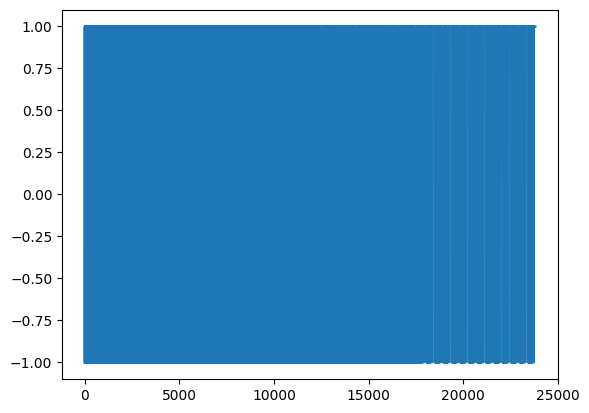

In [8]:
plt.plot(X_data_gen_train.features[:,-1,0])
plt.show()

In [9]:
Y_train_categorical=np.argmax(X_data_gen_train.y_classification,axis=1)

n_classes, counts=np.unique(Y_train_categorical, return_counts=True) 
print(n_classes, counts)
output_class_weights = class_weight.compute_class_weight('balanced', classes=n_classes, y=np.argmax(X_data_gen_train.y_classification,axis=1))

print(output_class_weights)

# Formula used - Naive method where
# weight = 1 - (no. of samples present / total no. of samples)
# So more the samples, lower the weight

weight_dict = {k: (1 - (v / counts.sum())) for k, v in enumerate(counts)}
print(weight_dict)


[0 1 2] [10825  6495  6495]
[0.73333333 1.22222222 1.22222222]
{0: 0.5454545454545454, 1: 0.7272727272727273, 2: 0.7272727272727273}


## Deep Learning Model

In [10]:
import tensorflow as tf
from tensorflow.keras.layers import (
    Input, Conv2D, BatchNormalization, Activation, MaxPooling2D, Dropout, Dense, Flatten
)
from tensorflow.keras.models import Model
from tensorflow.keras.regularizers import l2

In [11]:
from tensorflow.keras.layers import Reshape, GlobalAveragePooling2D

# Camadas comuns em 2D
def common_layers(input_layer, dropout_rate):
    x = Conv2D(64, (3, 3), padding="same")(input_layer)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling2D(pool_size=(3, 3), strides=1, padding="same")(x)
    x = Dropout(dropout_rate)(x)

    x = Conv2D(128, (3, 3), padding="same")(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling2D(pool_size=(3, 3), strides=2, padding="same")(x)
    x = Dropout(dropout_rate)(x)

    return x


# Camada head em 2D
def head_layer(conv_layer, num_classes, dropout_rate, l2_regularization, activation='linear', output_name=None):
    x = Conv2D(256, (3, 3), padding="same")(conv_layer)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling2D(pool_size=(3, 3), strides=2, padding="same")(x)
    x = Dropout(dropout_rate)(x)

    # Global Average Pooling para reduzir a dimensionalidade espacial
    #x = GlobalAveragePooling2D()(attention_output)  # (batch_size, channels)

    x = Flatten()(x)
    #x = Flatten()(x)
    # Camadas densas com regularização L2
    x = Dense(256, kernel_regularizer=l2(l2_regularization))(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Dropout(dropout_rate)(x)

    x = Dense(128, kernel_regularizer=l2(l2_regularization))(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Dropout(dropout_rate)(x)

    x = Dense(num_classes)(x)
    x = Activation(activation, name=output_name)(x)

    return x


# Criando o modelo completo
def create_model_2d(input_shape, num_classes, dropout_rate=0.2, l2_regularization=0.01):
    input_layer = Input(shape=input_shape)

    # Camadas comuns
    features = common_layers(input_layer, dropout_rate)

    # Head de classificação
    classification_output = head_layer(
        features, 
        num_classes=num_classes, 
        dropout_rate=dropout_rate, 
        l2_regularization=l2_regularization, 
        activation='softmax', 
        output_name='classification_head'
    )

    # Modelo final
    model = Model(inputs=input_layer, outputs=[classification_output], name="CNN_MultiHead_2D")
    return model


# Definindo parâmetros
input_shape_model = (1, input_shape[1], input_shape[0])  
num_classes = 3
dropout_rate = 0.3
l2_regularization = 0.01

# Criando o modelo
model_CNN_MultiHead = create_model_2d(input_shape_model, num_classes, dropout_rate, l2_regularization)

# Resumo do modelo
model_CNN_MultiHead.summary()
list_of_models=[model_CNN_MultiHead]



Model: "CNN_MultiHead_2D"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 1, 18, 40)]       0         
                                                                 
 conv2d (Conv2D)             (None, 1, 18, 64)         23104     
                                                                 
 batch_normalization (Batch  (None, 1, 18, 64)         256       
 Normalization)                                                  
                                                                 
 activation (Activation)     (None, 1, 18, 64)         0         
                                                                 
 max_pooling2d (MaxPooling2  (None, 1, 18, 64)         0         
 D)                                                              
                                                                 
 dropout (Dropout)           (None, 1, 18, 64)  

In [12]:
#Metrics and Loss Functions  

from tensorflow.keras import backend as K

def matthews_correlation_coefficient(y_true, y_pred):
    tp = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
    tn = K.sum(K.round(K.clip((1 - y_true) * (1 - y_pred), 0, 1)))
    fp = K.sum(K.round(K.clip((1 - y_true) * y_pred, 0, 1)))
    fn = K.sum(K.round(K.clip(y_true * (1 - y_pred), 0, 1)))

    num = tp * tn - fp * fn
    den = (tp + fp) * (tp + fn) * (tn + fp) * (tn + fn)
    return num / K.sqrt(den + K.epsilon())

def R2(y_true, y_pred): # squareds Pearson's correlation coef 
    SS_res =  K.sum(K.square( y_true-y_pred ))
    SS_tot = K.sum(K.square( y_true - K.mean(y_true) ) )
    return ( 1 - SS_res/(SS_tot - K.epsilon()) )

def NRMSE(y_true, y_pred): # normalized_root_mean_squared_error
    return 1-K.sqrt(K.mean(K.square(y_pred - y_true))) 

MSE= tf.keras.losses.mean_squared_error
MAE = tf.keras.losses.mean_absolute_error
MAPE = tf.keras.losses.mean_absolute_percentage_error

In [13]:
#Optimizers
def get_optimizer():
    optimizer1 = tf.keras.optimizers.Adam(learning_rate=0.0001, beta_1=0.9, beta_2=0.999, epsilon=1e-08, amsgrad=True, name="Adam")
    #optimizer1 = tf.keras.optimizers.RMSprop(learning_rate=0.001)
    #optimizer = optimizers.SGD(lr=params["lr"], decay=1e-6, momentum=0.9, nesterov=True)

    return optimizer1
    #

#Train options callbacks
    # Avalia se está tendo avanção de desempenho no treinamento/validação e para caso não tenha avanço 
EarlyStopping=tf.keras.callbacks.EarlyStopping( monitor="val_loss", patience=20, verbose=1, mode="min", restore_best_weights=True,)

    # verifica se está tendo avanço de desempenho durante o treinamento, caso não reduz integralmente o lr
reduceLr = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor = 0.01, patience = 5, min_lr=1e-20,verbose=1)



def checkpoints(model_name, cryptos):
    checkpoint_filepath =f'models/model_{model_name}_crypto_{cryptos}'
    csvLogger = tf.keras.callbacks.CSVLogger(checkpoint_filepath+'_history.csv', separator=',',append=True)
    model_checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(filepath=checkpoint_filepath, verbose=1, save_weights_only=False, monitor='val_loss', mode='min', save_best_only=True)
    print("Training model :", checkpoint_filepath)

    return csvLogger, model_checkpoint_callback

model_name = 'CNN_MultiHead_2D'

In [14]:
list_of_models=[model_CNN_MultiHead]

## Load Data And train

In [15]:
SHD=scrapingHistoricalData()

# Lista de criptomoedas
interval = '4h'#


In [16]:
import datetime
init_date = '2017-01-01'
#init_date = '2020-01-01'
init_date_object = datetime.datetime.strptime(init_date, '%Y-%m-%d').date()

date_now = datetime.date.today()

diff_years = date_now.year - init_date_object.year
year_window = 8


cryptos_list = [ 'BTC','ETH','SOL','XRP','ADA','DOT'] 
cryptos_list = ['BTC']

if year_window > diff_years:
    raise ValueError("O intervalo de anos (year_window) é maior do que o período disponível nos dados.")


BTC Dataset Period:2017-01-01 : 2025-05-02
The file Data_history\BTC_4h_2017-08-17_2025-04-23.csv exist in folder path.
self.pred_days 1
input data shape (19, 1, 30)
output data shape (19, 3)
Train data shape (12402,)
Vall data shape (1551,)
Test data shape (1552,)


d:\Projetos_python\Time_Series_Forecast\acoes\Processing\MarketIndicators.py:97: RuntimeWarning:

invalid value encountered in divide



self.pred_days 25


d:\Projetos_python\Time_Series_Forecast\acoes\Processing\DataLoaderPipeline.py:669: RuntimeWarning:

divide by zero encountered in log



input data shape (25113, 40, 18)
output data shape (25113, 3)
self.pred_days 25
input data shape (3073, 40, 18)
output data shape (3073, 3)
self.pred_days 25
input data shape (1512, 40, 18)
output data shape (1512, 3)
[0 1 2] [11415  6849  6849]
[0.73333333 1.22222222 1.22222222]
Training model : models/model_CNN_MultiHead_2D_crypto_BTC
------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Initing train for model: CNN_MultiHead_2D
Epoch 1/200



Epoch 1: val_loss improved from inf to 6.83713, saving model to models\model_CNN_MultiHead_2D_crypto_BTC
INFO:tensorflow:Assets written to: models\model_CNN_MultiHead_2D_crypto_BTC\assets


...

196/196 - 27s - loss: 0.8224 - accuracy: 0.7793 - f1_score: 0.7715 - matthews_correlation_coefficient: 0.6595 - val_loss: 1.1452 - val_accuracy: 0.6709 - val_f1_score: 0.6397 - val_matthews_correlation_coefficient: 0.4543 - lr: 1.0000e-04 - 27s/epoch - 138ms/step
Epoch 25/200

Epoch 25: val_loss improved from 1.14518 to 1.14113, saving model to models\model_CNN_MultiHead_2D_crypto_BTC
INFO:tensorflow:Assets written to: models\model_CNN_MultiHead_2D_crypto_BTC\assets


INFO:tensorflow:Assets written to: models\model_CNN_MultiHead_2D_crypto_BTC\assets


196/196 - 27s - loss: 0.7904 - accuracy: 0.7867 - f1_score: 0.7784 - matthews_correlation_coefficient: 0.6700 - val_loss: 1.1411 - val_accuracy: 0.6768 - val_f1_score: 0.6455 - val_matthews_correlation_coefficient: 0.4658 - lr: 1.0000e-04 - 27s/epoch - 136ms/step
Epoch 26/200

Epoch 26: val_loss improved from 1.14113 to 1.13293, saving model to models\model_CNN_MultiHead_2D_crypto_BTC
INFO:tensorflow:Assets written to: models\model_CNN_MultiHead_2D_crypto_BTC\assets


INFO:tensorflow:Assets written to: models\model_CNN_MultiHead_2D_crypto_BTC\assets


196/196 - 28s - loss: 0.7790 - accuracy: 0.7869 - f1_score: 0.7783 - matthews_correlation_coefficient: 0.6693 - val_loss: 1.1329 - val_accuracy: 0.6901 - val_f1_score: 0.6577 - val_matthews_correlation_coefficient: 0.4822 - lr: 1.0000e-04 - 28s/epoch - 141ms/step
Epoch 27/200

Epoch 27: val_loss did not improve from 1.13293
196/196 - 23s - loss: 0.7440 - accuracy: 0.7978 - f1_score: 0.7891 - matthews_correlation_coefficient: 0.6849 - val_loss: 1.1815 - val_accuracy: 0.6615 - val_f1_score: 0.6299 - val_matthews_correlation_coefficient: 0.4453 - lr: 1.0000e-04 - 23s/epoch - 116ms/step
Epoch 28/200

Epoch 28: val_loss did not improve from 1.13293
196/196 - 20s - loss: 0.7300 - accuracy: 0.7985 - f1_score: 0.7894 - matthews_correlation_coefficient: 0.6853 - val_loss: 1.1487 - val_accuracy: 0.6582 - val_f1_score: 0.6262 - val_matthews_correlation_coefficient: 0.4451 - lr: 1.0000e-04 - 20s/epoch - 101ms/step
Epoch 29/200

Epoch 29: val_loss did not improve from 1.13293
196/196 - 20s - loss: 

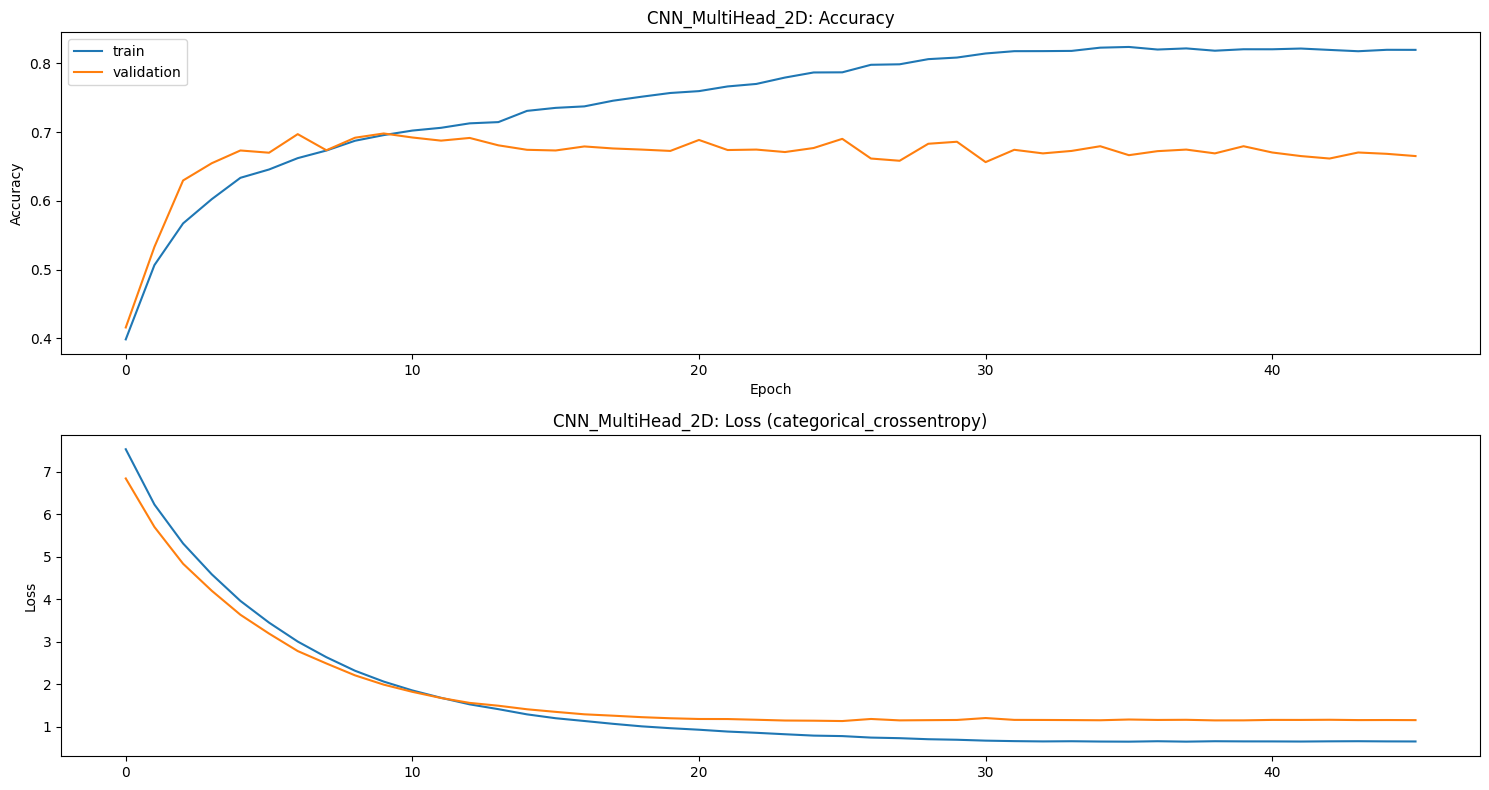

---------------------------------------------------------------------------------------------------------------------------------
CNN_MultiHead_2D



Model name: CNN_MultiHead_2D
48/48 [==============================] - 1s 9ms/step
CNN_MultiHead_2D  classification Accuracy 0.666005291005291


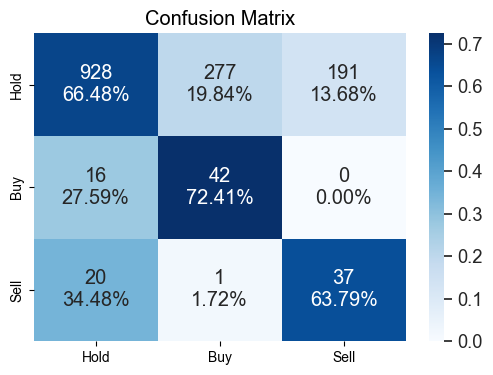

In [17]:
idx=0
for i, cryptos in enumerate(cryptos_list):

    for stride_year in range(0, diff_years-year_window+1):
        init_time=f'{init_date_object.year+stride_year}-01-01'

        look_year=init_date_object.year+stride_year+year_window
        if date_now.year == look_year:
            end_time=date_now.strftime('%Y-%m-%d')
        else:
            end_time=f'{look_year}-01-01'
        print(f'{cryptos} Dataset Period:{init_time} : {end_time}') 

        # Caminho do arquivo
        #file_folder = f'Data_history/{cryptos_list[0]}_{interval}_{init_time}_{end_time}.csv'
        try:
            file_folder = [crypto_data for crypto_data in glob("Data_history/*")  if cryptos in crypto_data][0]
        except:
            file_folder =""
            
        if os.path.exists(file_folder):
            print(f"The file {file_folder} exist in folder path.")
            cryptos_df=pd.read_csv(file_folder, index_col=0)

            #mask = (cryptos_df['Date'] >= init_time) & (cryptos_df['Date'] <= end_time)
            #cryptos_df = cryptos_df[mask]
            
            #cryptos_df.reset_index(drop=True, inplace=True)
            #cryptos_df.to_csv(file_folder)
            #print(f"Save the file {file_folder} in folder path.")
        else:
            print(f"Donwload the file {file_folder} from bincance history.")
            # Obtenha os dados históricos
            cryptos_df = SHD.get_crypto_historical_data([cryptos], interval, init_time, end_time)
        
        # split the data in train validation and test
        split_data=FeaturesDataGenerator().split_data
        X_train, X_val, T_train, T_val=split_data(cryptos_df['Close'].values, cryptos_df['Date'], factor=0.80)
        X_val, X_test, T_val, T_test=split_data(X_val.T, T_val, factor=0.5)

        print('Train data shape',X_train.shape)
        print('Vall data shape',X_val.shape)
        print('Test data shape',X_test.shape)

        # get train vall and test dataloader
        X_data_gen_train = FeaturesDataGenerator(cryptos_df[cryptos_df['Date'].isin(T_train)].iloc[:,:], datatype='2D', lookback = lookback, pred_days = pred_days, buy_sell_threshold=buy_sell_threshold, shuffle= shuffle, batch_size=batch_size, selected_features = features_indicators, data_augmentation=data_augmentation, min_max_norm_features=[min_norm, max_norm])
        X_data_gen_val = FeaturesDataGenerator(cryptos_df[cryptos_df['Date'].isin(T_val)].iloc[:,:], datatype='2D', lookback = lookback, pred_days = pred_days,  buy_sell_threshold=buy_sell_threshold, shuffle= shuffle, batch_size=batch_size, selected_features = features_indicators, data_augmentation=data_augmentation, min_max_norm_features=[min_norm, max_norm])
        X_data_gen_test = FeaturesDataGenerator(cryptos_df[cryptos_df['Date'].isin(T_test)].iloc[:,:], datatype='2D', lookback = lookback, pred_days = pred_days,  buy_sell_threshold=buy_sell_threshold, shuffle= False, batch_size=batch_size, selected_features = features_indicators, data_augmentation=False, min_max_norm_features=[min_norm, max_norm])

        # get classes weigths 
        Y_train_categorical=np.argmax(X_data_gen_train.y_classification,axis=1)
        n_classes, counts=np.unique(Y_train_categorical, return_counts=True) 
        print(n_classes, counts)
        output_class_weights = class_weight.compute_class_weight('balanced', classes=n_classes, y=np.argmax(X_data_gen_train.y_classification,axis=1))

        print(output_class_weights)
        output_class_weights = np.ones(3) 
        
        #weighted_categorical_crossentropy_loss= X_data_gen_train.weighted_categorical_crossentropy(output_class_weights)

        penalty_matrix = np.array([
            [0.0, 1.0, 1.0],  # Penalidade para classificar Hold como Buy ou Sell
            [0.5, 0.0, 2.0],  # Penalidade para classificar Buy como Hold (0.5) ou Sell (2.0)
            [0.5, 2.0, 0.0]   # Penalidade para classificar Sell como Hold (0.5) ou Buy (2.0)
        ])
        weighted_categorical_crossentropy_loss= X_data_gen_train.custom_weighted_categorical_crossentropy(output_class_weights, penalty_matrix)
        
        #weight_dict = {k: (1 - (v / counts.sum())) for k, v in enumerate(counts)}
        loss = weighted_categorical_crossentropy_loss
        #loss = X_data_gen_train.focal_loss(gamma=2.0, alpha=0.25)
        #loss = keras.losses.CategoricalCrossentropy()
        
        for idx_model, model in enumerate(list_of_models):

            if idx == 0:  
                optimizer = get_optimizer()
                csvLogger, model_checkpoint_callback  = checkpoints(model._name, cryptos)
                model.compile(loss=[loss], optimizer=optimizer, metrics=['accuracy', tfa.metrics.F1Score(num_classes=3, average='weighted'),matthews_correlation_coefficient])
                idx=1
            else:
                optimizer = get_optimizer()
                csvLogger, model_checkpoint_callback  = checkpoints(model._name, cryptos)
                model = trained_best_models[model._name]
                model.compile(loss=[loss], optimizer=optimizer, metrics=['accuracy',matthews_correlation_coefficient])




            print('------------------------------------------------------------------------------------------------------------------------------------------------------------------------')
            print(f'Initing train for model: {model._name}')

            history = model.fit(
                X_data_gen_train,
                epochs=200,
                callbacks=[EarlyStopping, reduceLr, model_checkpoint_callback, csvLogger],
                validation_data=X_data_gen_val,
                #shuffle=True,
                #class_weight=weight_dict,
                #class_weight=dict(enumerate([1, 1, 1])),
                verbose=2
            )
            # Assuming history_metric, history_metric_val, history are defined elsewhere

            fig, axes = plt.subplots(2, 1, figsize=(15, 8))  # Create subplots programmatically

            # Plot accuracy, sharing x-axis with NRMSE
            axes[0].plot(history.history['accuracy'])
            axes[0].plot(history.history['val_accuracy'])
            axes[0].set_title(f'{model._name}: Accuracy')
            axes[0].set_ylabel('Accuracy')
            axes[0].set_xlabel('Epoch')  # Shared x-axis label
            axes[0].legend(['train', 'validation'], loc='upper left')

            # Plot loss
            axes[1].plot(history.history['loss'])
            axes[1].plot(history.history['val_loss'])
            axes[1].set_title(f'{model._name}: Loss (categorical_crossentropy)')
            axes[1].set_ylabel('Loss')

            # Adjust spacing and margins (optional)
            plt.subplots_adjust(left=0.1, bottom=0.15, right=0.9, top=0.9, wspace=0.2)

            # Fine-tune spacing (optional)
            plt.tight_layout()

            plt.show()
        trained_best_models={}
        print("---------------------------------------------------------------------------------------------------------------------------------")
        for model in list_of_models:
            print(model.name)
            checkpoint_filepath =f'models/model_{model_name}_crypto_{cryptos}'
            trained_best_models[f'{model._name}']=tf.keras.models.load_model(
                checkpoint_filepath, 
                custom_objects={'loss': weighted_categorical_crossentropy_loss, 'matthews_correlation_coefficient': matthews_correlation_coefficient}, 
                compile=False)

            print('Model name:',model_name)

            x_data=X_data_gen_test.apply_NomrMinmax(X_data_gen_test.features, min_norm, max_norm, axis=0)
            x_data = np.transpose(x_data, [0, 2, 1]).reshape(-1, 1, input_shape[1], input_shape[0])
            
            label_pred = trained_best_models[model_name].predict(x_data)
            print(model_name,' classification Accuracy',
                            utils.f1_score(np.argmax(X_data_gen_test.y_classification,axis=1),
                            np.argmax(label_pred,axis=1),average="micro"))

            cf_matrix = utils.confusion_matrix(np.argmax(X_data_gen_test.y_classification,axis=1),np.argmax(label_pred,axis=1))
            
            try:
                utils.plot_confusion_matrix(gesture_list= ['Hold','Buy','Sell'], cf_matrix=cf_matrix)
            except:
                print(cf_matrix)


In [18]:
[crypto_data for crypto_data in glob("Data_history/*")]

['Data_history\\ADA_4h_2018-04-17_2025-04-23.csv',
 'Data_history\\BTC_4h_2017-08-17_2025-04-23.csv',
 'Data_history\\DOT_4h_2020-08-18_2025-04-23.csv',
 'Data_history\\ENA_4h_2024-04-02_2025-02-27.csv',
 'Data_history\\ETH_4h_2017-08-17_2025-04-23.csv',
 'Data_history\\FET_4h_2019-02-28_2025-02-27.csv',
 'Data_history\\RAY_4h_2021-08-10_2025-02-27.csv',
 'Data_history\\SOL_4h_2020-08-11_2025-04-23.csv',
 'Data_history\\XRP_4h_2018-05-04_2025-04-23.csv']

In [19]:
file_folder = [crypto_data for crypto_data in glob("Data_history/*")  if cryptos in crypto_data][0]

In [20]:
checkpoint_filepath

'models/model_CNN_MultiHead_2D_crypto_BTC'

In [21]:
output_class_weights

array([1., 1., 1.])

### Save the model parameters to inference

In [22]:
import json
model_data_parameters = {
    'symbol':cryptos_list,
    'model_name':model_name,
    'features_indicators': features_indicators,
    'pred_days': pred_days,
    'buy_sell_threshold': buy_sell_threshold,
    'lookback': lookback,
    'batch_size': batch_size,
    'shuffle': shuffle,
    'data_augmentation': data_augmentation,
    'min_norm': min_norm,
    'max_norm': max_norm,
    'trade': trade,
}

# Salve os dados em um arquivo JSON
with open(f'{checkpoint_filepath}/config.json', 'w') as file:
    json.dump(model_data_parameters, file, indent=4)

### Vall Data 

Model name: CNN_MultiHead_2D


97/97 [==============================] - 1s 9ms/step
CNN_MultiHead_2D  classification Accuracy 0.6749105109013993


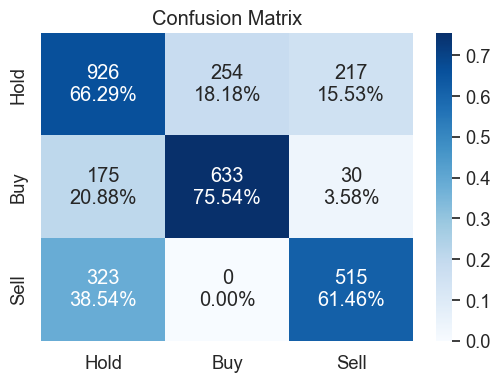

In [23]:
model_name = "CNN_MultiHead_2D"  
print('Model name:',model_name)

x_data=X_data_gen_val.apply_NomrMinmax(X_data_gen_val.features, min_norm,  max_norm, axis=0)
x_data = np.transpose(x_data, [0, 2, 1]).reshape(-1, 1, input_shape[1], input_shape[0])

label_pred = trained_best_models[model_name].predict(x_data)
print(model_name,' classification Accuracy',
                utils.f1_score(np.argmax(X_data_gen_val.y_classification,axis=1),
                np.argmax(label_pred,axis=1),average="micro"))

cf_matrix = utils.confusion_matrix(np.argmax(X_data_gen_val.y_classification,axis=1),np.argmax(label_pred,axis=1))
 
try:
    utils.plot_confusion_matrix(gesture_list= ['Hold','Buy','Sell'], cf_matrix=cf_matrix)
except:
    print(cf_matrix)

### Backtest

In [24]:
# Classe para gerenciar o backtesting
import matplotlib.pyplot as plt

class Backtester:
    def __init__(self, initial_balance, data, transaction_cost=0.000001):
        self.initial_balance = initial_balance
        self.data = data
        self.balance = initial_balance
        self.position = 0
        self.portfolio_value = []
        self.transaction_cost = transaction_cost
        self.trades = []

    def execute_trade(self, signal, price):
        if signal == 'Buy':
            if self.balance > 0:
                cost = self.balance * self.transaction_cost
                self.position = (self.balance - cost) / price
                self.trades.append({'Action': 'Buy', 'Price': price, 'Position': self.position})
                self.balance = 0
        
        elif signal == 'Sell':
            if self.position > 0:
                proceeds = self.position * price
                cost = proceeds * self.transaction_cost
                self.balance = proceeds - cost
                self.trades.append({'Action': 'Sell', 'Price': price, 'Balance': self.balance})
                self.position = 0

        elif signal not in ['Hold']:
            print('balance:',self.balance)
            print('positi:',self.position)
            raise ValueError(f"Invalid signal: {signal}")

    def run(self, signals):
        for i in range(len(self.data)):
            price = self.data['Close'].iloc[i]
            signal = signals[i]
            self.execute_trade(signal, price)
            portfolio_value = self.balance + (self.position * price)
            self.portfolio_value.append(portfolio_value)

    def plot_portfolio_value(self):
        plt.figure(figsize=(10, 6))
        plt.plot(self.portfolio_value, label='Portfolio Value')
        plt.title('Portfolio Value Over Time')
        plt.xlabel('Time')
        plt.ylabel('Portfolio Value')
        plt.legend()
        plt.show()

    def calculate_metrics(self):
        final_portfolio_value = self.portfolio_value[-1]
        roi = (final_portfolio_value - self.initial_balance) / self.initial_balance * 100
        max_drawdown = min(self.portfolio_value) / self.initial_balance - 1
        return {
            'Final Portfolio Value': final_portfolio_value,
            'ROI (%)': roi,
            'Max Drawdown (%)': max_drawdown * 100
        }

# Função para gerar sinais fictícios
def generate_signals(signals):
    trade_signals = ['Hold']
    for i in range(1,len(signals)):
        if signals[i] == 'Buy' and signals[i-1] == 'Buy':
            trade_signals.append('Hold')
        elif signals[i] == 'Buy' and signals[i-1] == 'Hold':
            trade_signals.append('Buy')
        elif signals[i] == 'Sell' and signals[i-1] == 'Sell':
            trade_signals.append('Hold')
        elif signals[i] == 'Sell' and signals[i-1] == 'Hold':
            trade_signals.append('Sell')
        else:
            trade_signals.append('Hold')


    return trade_signals

self.pred_days 30
input data shape (10679, 40, 18)
output data shape (10679, 3)
334/334 [==============================] - 5s 14ms/step
(array(['Buy', 'Hold', 'Sell'], dtype='<U4'), array([2263, 6854, 1562], dtype=int64))


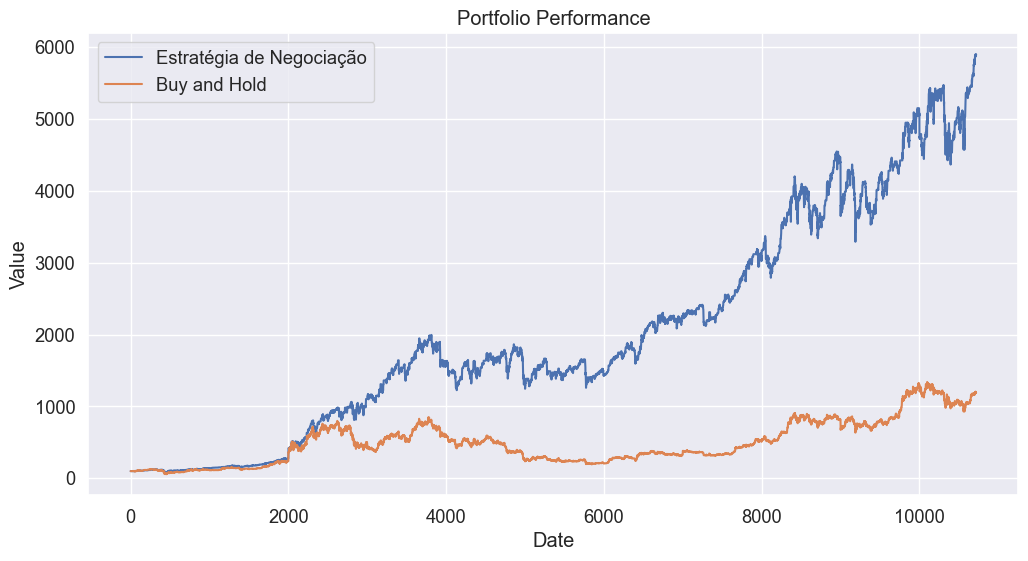

Retorno da Estratégia de Negociação: 5790.30%
Retorno da Estratégia de Buy and Hold: 1092.06%


In [28]:
# Parâmetros iniciais
#symbol=['BTC']
symbol = [cryptos_list[0]]
interval = '4h' 
start_time = '2020-01-01'
initial_balance = 100

# Coleta de dados
data = SHD.get_crypto_historical_data(symbol, interval, start_time)

dataGen_inference = FeaturesDataGenerator(data, datatype = '2D', lookback = lookback, pred_days = pred_days, shuffle= False, batch_size=1, selected_features = features_indicators, data_augmentation=False, min_max_norm_features=[min_norm, max_norm])
if data.empty:
    print("Nenhum dado encontrado.")
else:
    # Geração de sinais e backtesting

    x_data_inference=dataGen_inference.comput_features(data, pred_days=0)
    x_data=dataGen_inference.apply_NomrMinmax(x_data_inference, min_norm, max_norm, axis=0)
    x_data = np.transpose(x_data, [0, 2, 1]).reshape(-1, 1, input_shape[1], input_shape[0])
    
    # list_of_models = ['MLP', 'GRU', 'CNN_LSTM_MultiHead', 'CNN_MultiHead', 'LSTM', 'LSTM_AT']
    model_name='CNN_MultiHead_2D'
    label_pred = trained_best_models[model_name].predict(x_data)

    signals_model = [trade[label] for label in np.argmax(label_pred[:], axis=1)]
    print(np.unique(signals_model, return_counts=True))

    init_signals= ['Hold']*lookback
    
    #trade_signals=init_signals + generate_signals(signals_model)

    trade_signals = init_signals + signals_model
    

    backtester = Backtester(initial_balance, data)
    backtester.run(trade_signals)
    # backtester.plot_results()

    # Estratégia de buy and hold
    buy_and_hold = Backtester(initial_balance, data)
    signals =  init_signals + ['Buy'] + ['Hold'] * (len(data) - 1)
    buy_and_hold.run(signals)
    buy_and_hold_value = buy_and_hold.portfolio_value

    # Plotar resultados
    plt.figure(figsize=(12, 6))
    plt.plot(backtester.data.index, backtester.portfolio_value, label='Estratégia de Negociação')
    plt.plot(buy_and_hold.data.index, buy_and_hold_value, label='Buy and Hold')
    plt.xlabel('Date')
    plt.ylabel('Value')
    plt.title('Portfolio Performance')
    plt.legend()
    plt.show()

    # Calcular retorno
    backtester_return = (backtester.portfolio_value[-1] - initial_balance) / initial_balance
    buy_and_hold_return = (buy_and_hold_value[-1] - initial_balance) / initial_balance

    print(f"Retorno da Estratégia de Negociação: {backtester_return * 100:.2f}%")
    print(f"Retorno da Estratégia de Buy and Hold: {buy_and_hold_return * 100:.2f}%")

In [26]:
print(f"Modelo: {backtester.calculate_metrics()}")
print(f"BuyHold: {buy_and_hold.calculate_metrics()}")

Modelo: {'Final Portfolio Value': 645.087622627605, 'ROI (%)': 545.087622627605, 'Max Drawdown (%)': -0.00010000000000287557}
BuyHold: {'Final Portfolio Value': 570.1572728607978, 'ROI (%)': 470.1572728607978, 'Max Drawdown (%)': -0.09924974991222246}


10719
Calculating labels
10719
Calculating labels


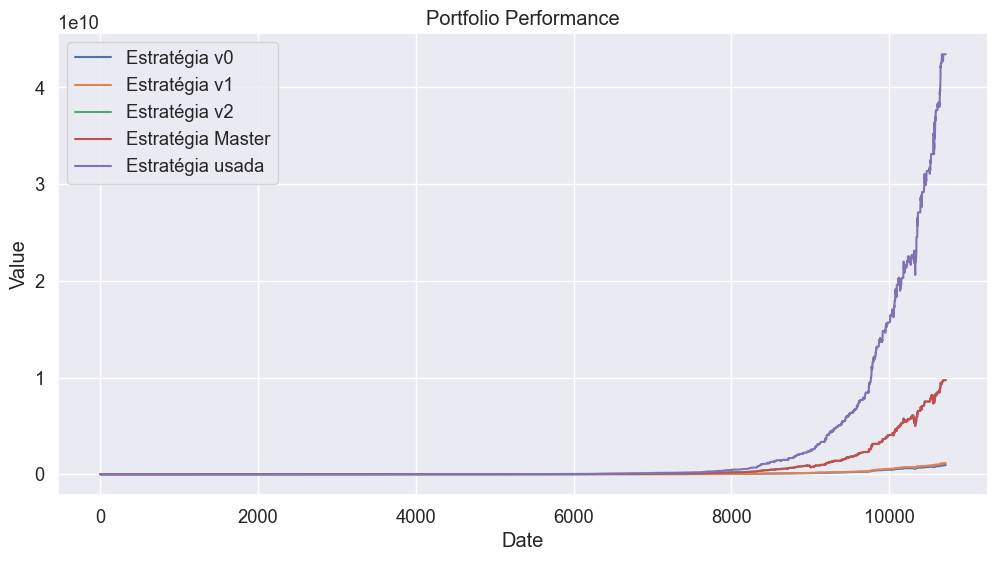

Estratégia v0: 947325524.49%
Estratégia v1: 1138774022.51%
Estratégia v2: 9733666647.86%
Estratégia Master: 9733666647.86%
Estratégia Master Testada: 43434813359.35%


In [29]:
# Implementar todas as estratégias
pred_days = 30
label_data_v0 = dataGen_inference.label_data_v0(close_prices=data['Close'].values, window=pred_days)
label_data_v1 = dataGen_inference.label_data_v1(close_prices=data['Close'].values, window=pred_days)
label_data_v2 = dataGen_inference.label_data__(close_prices=data['Close'].values, window=pred_days)
label_data_master = dataGen_inference.label_data_master(close_prices=data['Close'].values, window=pred_days)
label_data = dataGen_inference.label_data(close_prices=data['Close'].values, window=pred_days)

# Convertar as labels em sinais de compra e venda
trade_signals_v0 = [("Buy" if np.allclose(label, [0, 1, 0]) else "Sell" if np.allclose(label, [0, 0, 1]) else "Hold") 
    for label in label_data_v0]
trade_signals_v1 = [("Buy" if np.allclose(label, [0, 1, 0]) else "Sell" if np.allclose(label, [0, 0, 1]) else "Hold") 
    for label in label_data_v1]
trade_signals_v2 = [("Buy" if np.allclose(label, [0, 1, 0]) else "Sell" if np.allclose(label, [0, 0, 1]) else "Hold") 
    for label in label_data_v2]
trade_signals_master = [("Buy" if np.allclose(label, [0, 1, 0]) else "Sell" if np.allclose(label, [0, 0, 1]) else "Hold") 
    for label in label_data_master]
trade_signals = [("Buy" if np.allclose(label, [0, 1, 0]) else "Sell" if np.allclose(label, [0, 0, 1]) else "Hold") 
    for label in label_data]

# Realizar o backtest
backtester_v0 = Backtester(initial_balance, data)
backtester_v0.run(trade_signals_v0)

backtester_v1 = Backtester(initial_balance, data)
backtester_v1.run(trade_signals_v1)

backtester_v2 = Backtester(initial_balance, data)
backtester_v2.run(trade_signals_v2)

backtester_master = Backtester(initial_balance, data)
backtester_master.run(trade_signals_master)

backtester = Backtester(initial_balance, data)
backtester.run(trade_signals)

# Plotar os resultados
plt.figure(figsize=(12, 6))
plt.plot(backtester_v0.data.index, backtester_v0.portfolio_value, label='Estratégia v0')
plt.plot(backtester_v1.data.index, backtester_v1.portfolio_value, label='Estratégia v1')
plt.plot(backtester_v2.data.index, backtester_v2.portfolio_value, label='Estratégia v2')
plt.plot(backtester_master.data.index, backtester_master.portfolio_value, label='Estratégia Master')
plt.plot(backtester.data.index, backtester.portfolio_value, label='Estratégia usada')
plt.xlabel('Date')
plt.ylabel('Value')
plt.title('Portfolio Performance')
plt.legend()
plt.show()

# Calcular o retorno de cada estratégia
retorno_v0 = (backtester_v0.portfolio_value[-1] - initial_balance) / initial_balance
retorno_v1 = (backtester_v1.portfolio_value[-1] - initial_balance) / initial_balance
retorno_v2 = (backtester_v2.portfolio_value[-1] - initial_balance) / initial_balance
retorno_master = (backtester_master.portfolio_value[-1] - initial_balance) / initial_balance
retorno_master_tested = (backtester.portfolio_value[-1] - initial_balance) / initial_balance

# Imprimir os resultados
print(f"Estratégia v0: {retorno_v0 * 100:.2f}%")
print(f"Estratégia v1: {retorno_v1 * 100:.2f}%")
print(f"Estratégia v2: {retorno_v2 * 100:.2f}%")
print(f"Estratégia Master: {retorno_master * 100:.2f}%")
print(f"Estratégia Master Testada: {retorno_master_tested * 100:.2f}%")